In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# LOADING DATA

In [16]:
dm1 = pd.read_csv("data/prices_round_2_day_0.csv",delimiter=";") 
d1 = pd.read_csv("data/prices_round_2_day_1.csv",delimiter=";") 
d0 = pd.read_csv("data/prices_round_2_day_2.csv",delimiter=";") 



JAMS

In [17]:
jm1 = dm1[dm1["product"] == "JAMS"]
j1 = d1[d1["product"] == "JAMS"]
j0 = d0[d0["product"] == "JAMS"]


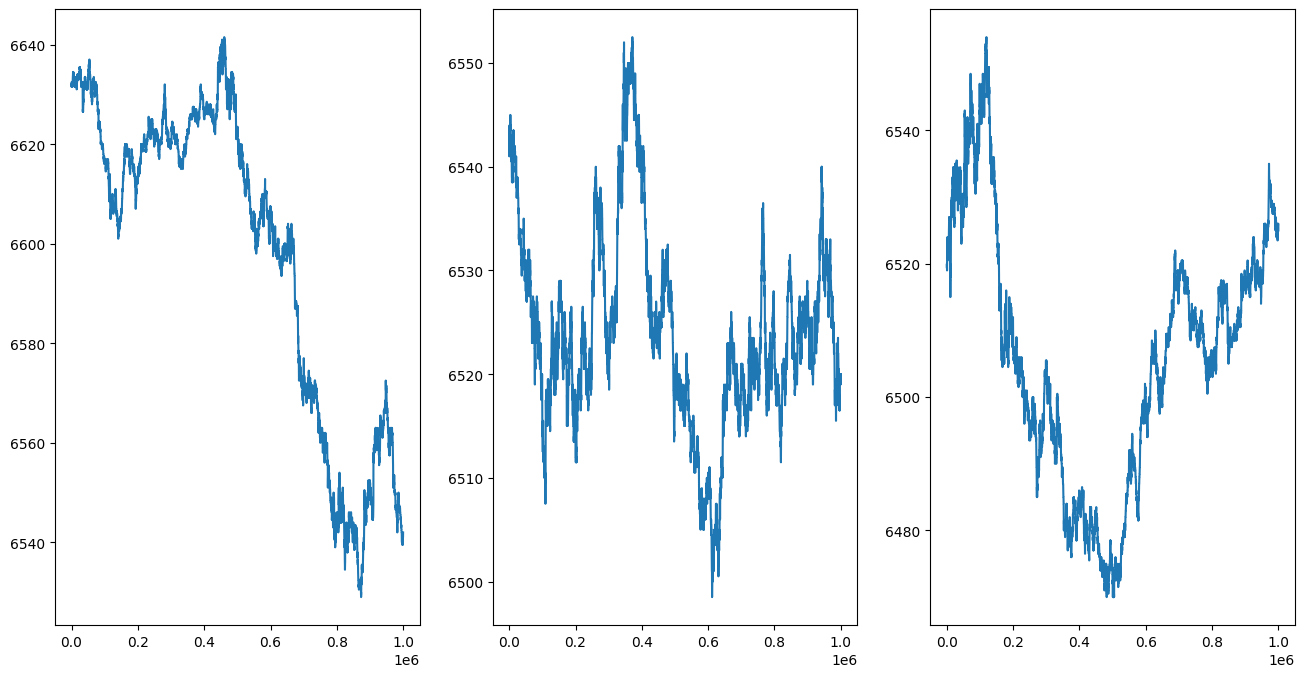

In [23]:
fig ,axes = plt.subplots(1,3, figsize=(16,8))
axes[0].plot(jm1["timestamp"],jm1["mid_price"])
axes[1].plot(j1["timestamp"],j1["mid_price"])
axes[2].plot(j0["timestamp"],j0["mid_price"])


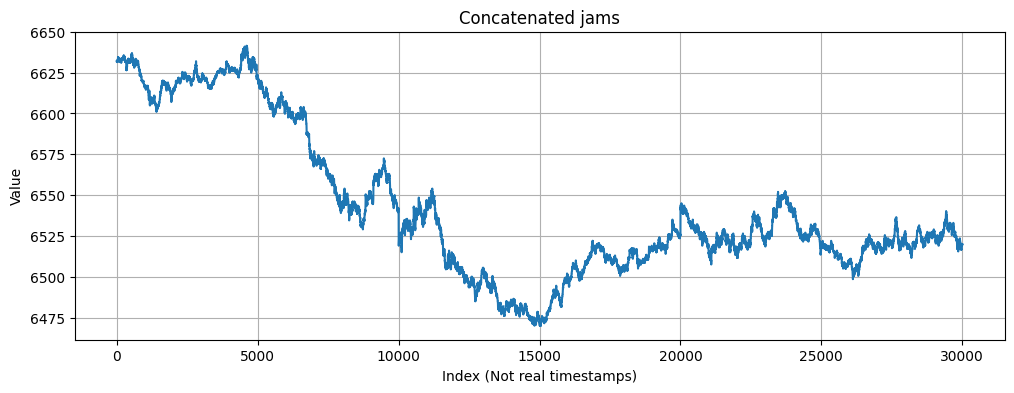

In [21]:
jm1r = jm1["mid_price"].reset_index(drop=True)
j0r = j0["mid_price"].reset_index(drop=True)
j1r = j1["mid_price"].reset_index(drop=True)


j_concat = pd.concat([jm1r, j0r, j1r]).reset_index(drop=True)
plt.figure(figsize=(12, 4))
plt.plot(j_concat)
plt.title("Concatenated jams")
plt.xlabel("Index (Not real timestamps)")
plt.ylabel("Value")
plt.grid(True)
plt.show()

Jams day 1 likely mean revering

In [24]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(j1["mid_price"].dropna())

print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value}')

if result[1] < 0.05:
    print("✅ The series is likely stationary (mean-reverting).")
else:
    print("❌ The series likely has a unit root (not mean-reverting).")

ADF Statistic: -2.9958021808297164
p-value: 0.03528828779000357
Critical Values:
   1%: -3.4310044252361025
   5%: -2.861829217009766
   10%: -2.5669239450765904
✅ The series is likely stationary (mean-reverting).


In [25]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(jm1["mid_price"].dropna())

print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value}')

if result[1] < 0.05:
    print("✅ The series is likely stationary (mean-reverting).")
else:
    print("❌ The series likely has a unit root (not mean-reverting).")

ADF Statistic: -0.2373730735405156
p-value: 0.9339177432273871
Critical Values:
   1%: -3.431005409094333
   5%: -2.8618296517685877
   10%: -2.566924176499291
❌ The series likely has a unit root (not mean-reverting).


In [26]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(j0["mid_price"].dropna())

print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value}')

if result[1] < 0.05:
    print("✅ The series is likely stationary (mean-reverting).")
else:
    print("❌ The series likely has a unit root (not mean-reverting).")

ADF Statistic: -1.3717500548395527
p-value: 0.595742089160432
Critical Values:
   1%: -3.4310044252361025
   5%: -2.861829217009766
   10%: -2.5669239450765904
❌ The series likely has a unit root (not mean-reverting).


as u can see nigges there is a regime change at the end where confiture bde yerkrech chwy

0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
           ...   
29995    0.000057
29996    0.000057
29997    0.000057
29998    0.000057
29999    0.000057
Name: mid_price, Length: 30000, dtype: float64


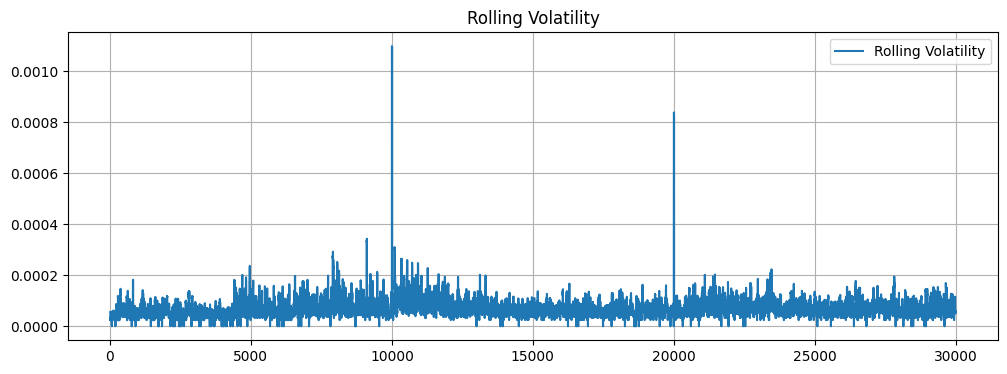

In [27]:
returns = j_concat.pct_change() 

rolling_volatility = returns.rolling(window=10).std()
print(rolling_volatility)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(rolling_volatility, label="Rolling Volatility")
plt.title("Rolling Volatility")
plt.legend()
plt.grid(True)
plt.show()

gon try to use ap(n) to predict order flow n shi idk tf m doin

In [31]:
tm1 = pd.read_csv("data/trades_round_2_day_-1.csv",delimiter=";")
t0 = pd.read_csv("data/trades_round_2_day_0.csv",delimiter=";")
t1 = pd.read_csv("data/trades_round_2_day_1.csv",delimiter=";")
tjm1 = tm1[tm1["symbol"] == "JAMS"][["timestamp","price","quantity"]]
tj0 = t0[t0["symbol"] == "JAMS"][["timestamp","price","quantity"]]
tj1 = t1[t1["symbol"] == "JAMS"][["timestamp","price","quantity"]]

trades_comb=pd.concat([tjm1, tj0, tj1], ignore_index=True)
trades_comb

,timestamp,price,quantity
0,400,6671.0,9
1,1200,6674.0,6
2,1800,6673.0,7
3,2500,6670.0,3
4,3200,6672.0,9
...,...,...,...
3467,997600,6520.0,9
3468,997800,6520.0,10
3469,998400,6520.0,4
3470,998900,6519.0,12


In [32]:

trades_comb['price_diff'] = trades_comb['price'].diff()
trades_comb['sign'] = trades_comb['price_diff'].apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))

trades_comb['order_flow'] = trades_comb['sign'] * trades_comb['quantity']

trades_comb = trades_comb.dropna(subset=['price_diff', 'sign'])

trades_comb = trades_comb[['timestamp', 'price', 'quantity', 'order_flow']]

df_order_flow = trades_comb.sort_values(by='timestamp').reset_index(drop=True)

df_order_flow.head()

,timestamp,price,quantity,order_flow
0,200,6542.0,11,0
1,200,6543.0,9,9
2,500,6631.0,10,-10
3,700,6542.0,6,-6
4,1200,6674.0,6,6


In [33]:
from statsmodels.tsa.ar_model import AutoReg

model = AutoReg(df_order_flow['order_flow'], lags=5)  
model_fitted = model.fit()

predictions = model_fitted.predict(start=len(df_order_flow), end=len(df_order_flow)+5)


print(predictions)

3471   -0.600420
3472   -0.510357
3473   -0.258305
3474   -0.171890
3475   -0.169913
3476   -0.176687
dtype: float64


In [34]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(df_order_flow['order_flow'], order=(5, 1, 0))
model_arima_fitted = model_arima.fit()
predictions_arima = model_arima_fitted.predict(start=len(df_order_flow), end=len(df_order_flow)+5)


print(predictions_arima)

3471   -1.092611
3472    0.479339
3473    2.891107
3474    1.562878
3475    0.571333
3476    0.688332
Name: predicted_mean, dtype: float64


testing

In [35]:
jm1rr = jm1.reset_index(drop=True)
j0rr = j0.reset_index(drop=True)
j1rr = j1.reset_index(drop=True)

j_concatr = pd.concat([jm1rr, j0rr, j1rr]).reset_index(drop=True)
trades_comb.shape , j_concatr.shape


((3471, 4), (30000, 17))

In [36]:
import time

start_time = time.time()
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
window_size = 50
model = ARIMA(j_concat[:window_size], order=(1, 1, 0))
model_fit = model.fit()
forecast = list(model_fit.forecast())[0]
print(forecast)
end_time = time.time()

print(f"Execution time: {end_time - start_time:.4f} seconds")

6634.162776526749
Execution time: 0.0140 seconds


In [118]:
'''
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA



window_size = 50  
cash = 100000
position = 0
portfolio = []

for t in range(window_size, 10000):
    print(t)
    train_series = j_concat[:t]
    current_price = j_concat[t]
    model = ARIMA(train_series, order=(1, 1, 0))
    model_fit = model.fit()
    forecast = list(model_fit.forecast())[0]

        
    if forecast > current_price:
            
        quantity = cash // current_price
        position += quantity
        cash -= quantity * current_price
    else:
        cash += position * current_price
        position = 0
            
    
    portfolio_value = cash + position * current_price
    portfolio.append(portfolio_value)

plt.plot(range(window_size,10000), portfolio)

'''


'\nimport pandas as pd\nfrom statsmodels.tsa.arima.model import ARIMA\n\n\n\nwindow_size = 50  \ncash = 100000\nposition = 0\nportfolio = []\n\nfor t in range(window_size, 10000):\n    print(t)\n    train_series = j_concat[:t]\n    current_price = j_concat[t]\n    model = ARIMA(train_series, order=(1, 1, 0))\n    model_fit = model.fit()\n    forecast = list(model_fit.forecast())[0]\n\n\n    if forecast > current_price:\n\n        quantity = cash // current_price\n        position += quantity\n        cash -= quantity * current_price\n    else:\n        cash += position * current_price\n        position = 0\n\n\n    portfolio_value = cash + position * current_price\n    portfolio.append(portfolio_value)\n\nplt.plot(range(window_size,10000), portfolio)\n\n'

In [37]:
from statsmodels.tsa.stattools import adfuller

# Assume you have a time series 'data'
result = adfuller(j_concat.diff().dropna())

# Output the test statistic, p-value, and critical values
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:", result[4])


ADF Statistic: -84.14907392544077
p-value: 0.0
Critical Values: {'1%': -3.43056803166244, '5%': -2.861636364100729, '10%': -2.566821291670243}


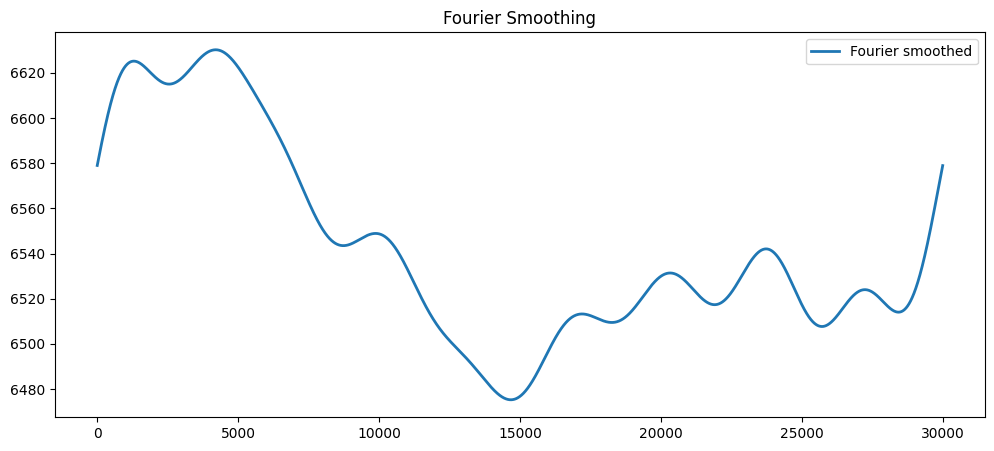

In [38]:
import numpy as np
import matplotlib.pyplot as plt
fft_vals = np.fft.fft(j_concat)
n_keep = 10  
fft_filtered = np.copy(fft_vals)
fft_filtered[n_keep:-n_keep] = 0
smoothed_signal = np.fft.ifft(fft_filtered).real
plt.figure(figsize=(12, 5))
#plt.plot(j_concat, label='Original (noisy)')
plt.plot(smoothed_signal, label='Fourier smoothed', linewidth=2)
plt.legend()
plt.title("Fourier Smoothing")
plt.show()

In [39]:
def ewma(prices: list[float], alpha: float = 0.5) -> float:
        ewma_value = prices[0]
        for price in prices[1:]:
            ewma_value = alpha * price + (1 - alpha) * ewma_value
        return ewma_value

df_j = pd.DataFrame(pd.Series(j_concat), columns=['mid_price'])
df_j["ewma"] = df_j["mid_price"].expanding().apply(ewma)
df_j["ewma2"] = df_j["mid_price"].ewm(span=50).mean()

In [56]:
df_j["pricedif"] = df_j["mid_price"].diff()
df_j["pricedif"][0] = 0
df_j["ewmadiff"] = df_j["pricedif"].ewm(span=50).mean()

In [57]:
df_j["ewmadiff"]

0        0.000000
1       -0.255000
2        0.006799
3        0.004996
4        0.003915
           ...   
29995    0.038181
29996    0.017075
29997    0.016406
29998    0.035370
29999    0.033983
Name: ewmadiff, Length: 30000, dtype: float64

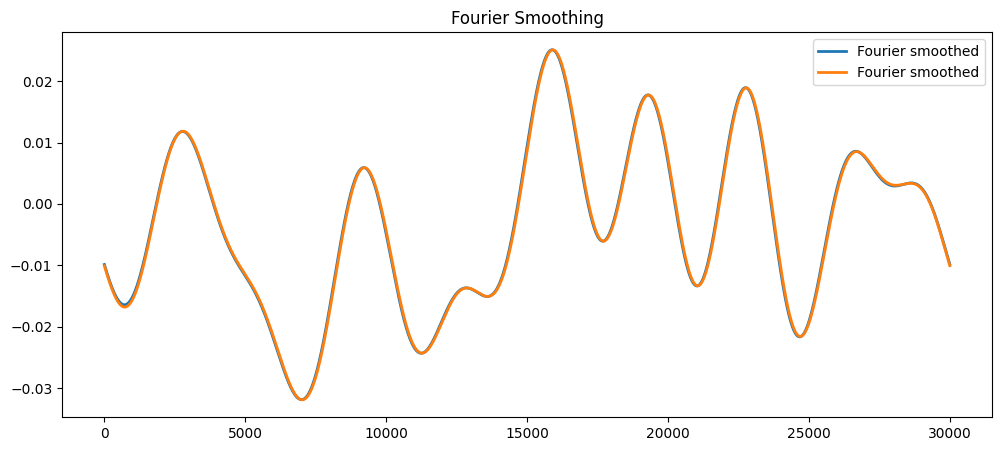

In [58]:
import numpy as np
import matplotlib.pyplot as plt
fft_vals = np.fft.fft(df_j["ewmadiff"])
n_keep = 10  
fft_filtered = np.copy(fft_vals)
fft_filtered[n_keep:-n_keep] = 0
smoothed_signal = np.fft.ifft(fft_filtered).real

fft_vals2 = np.fft.fft(df_j["pricedif"])
n_keep = 10  
fft_filtered2 = np.copy(fft_vals2)
fft_filtered2[n_keep:-n_keep] = 0
smoothed_signal2 = np.fft.ifft(fft_filtered2).real
plt.figure(figsize=(12, 5))
#plt.plot(j_concat, label='Original (noisy)')
plt.plot(smoothed_signal2, label='Fourier smoothed', linewidth=2)
plt.plot(smoothed_signal, label='Fourier smoothed', linewidth=2)
plt.legend()
plt.title("Fourier Smoothing")
plt.show()

Croissant

In [59]:
cm1 = dm1[dm1["product"] == "CROISSANTS"]
c1 = d1[d1["product"] == "CROISSANTS"]
c0 = d0[d0["product"] == "CROISSANTS"]


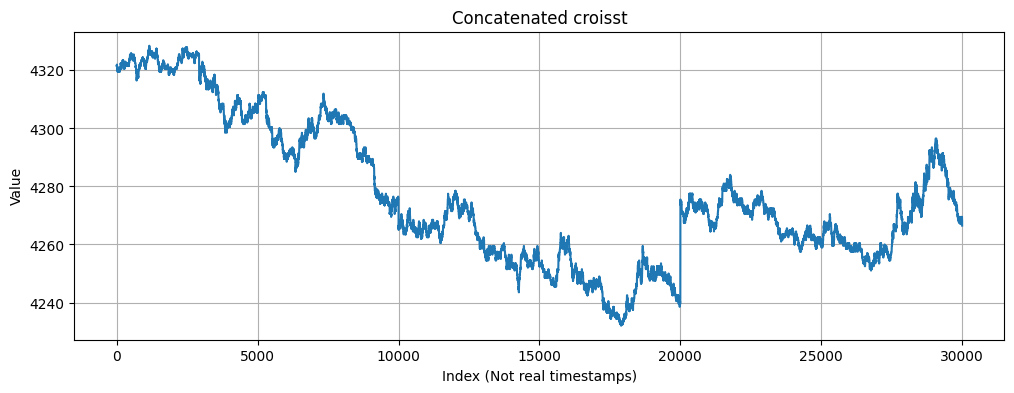

In [60]:
cm1r = cm1["mid_price"].reset_index(drop=True)
c0r = c0["mid_price"].reset_index(drop=True)
c1r = c1["mid_price"].reset_index(drop=True)


c_concat = pd.concat([cm1r, c0r, c1r]).reset_index(drop=True)
plt.figure(figsize=(12, 4))
plt.plot(c_concat)
plt.title("Concatenated croisst")
plt.xlabel("Index (Not real timestamps)")
plt.ylabel("Value")
plt.grid(True)
plt.show()

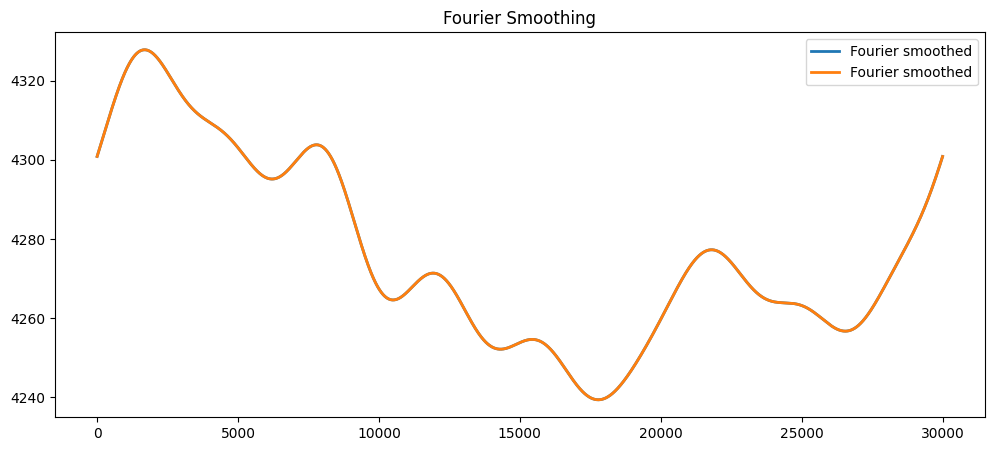

In [61]:
import numpy as np
import matplotlib.pyplot as plt
fft_vals = np.fft.fft(j_concat)
n_keep = 10  
fft_filtered = np.copy(fft_vals)
fft_filtered[n_keep:-n_keep] = 0
smoothed_signal = np.fft.ifft(fft_filtered).real

fft_vals2 = np.fft.fft(c_concat)
n_keep = 10  
fft_filtered2 = np.copy(fft_vals2)
fft_filtered2[n_keep:-n_keep] = 0
smoothed_signal2 = np.fft.ifft(fft_filtered2).real
plt.figure(figsize=(12, 5))
plt.plot(smoothed_signal2, label='Fourier smoothed', linewidth=2)
plt.plot(smoothed_signal2, label='Fourier smoothed', linewidth=2)
plt.legend()
plt.title("Fourier Smoothing")
plt.show()

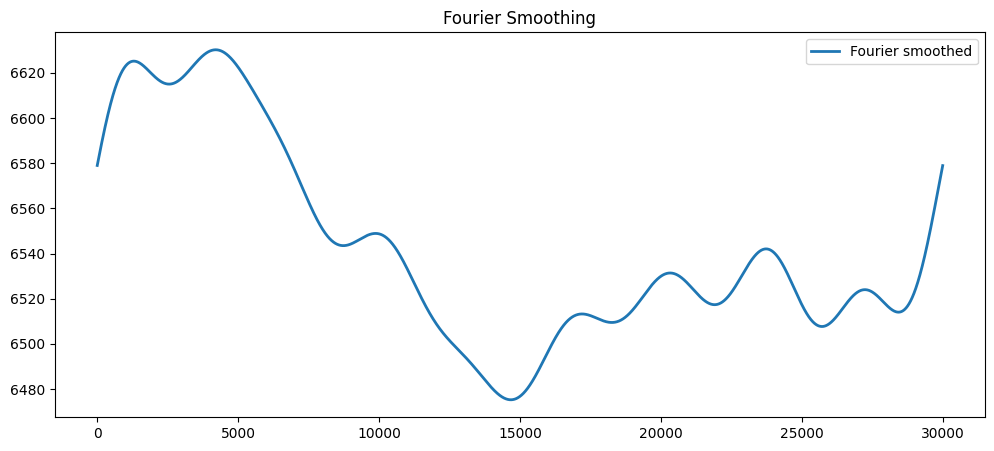

In [62]:
plt.figure(figsize=(12, 5))
plt.plot(smoothed_signal, label='Fourier smoothed', linewidth=2)
plt.legend()
plt.title("Fourier Smoothing")
plt.show()

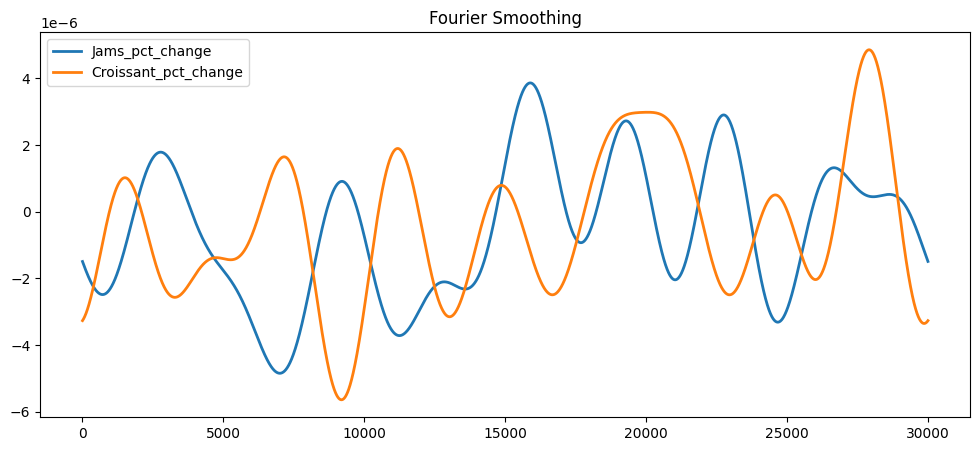

In [63]:
crossdf = pd.DataFrame(pd.Series(j_concat))
crossdf["mid_price_c"] = c_concat
crossdf["jpct"] = crossdf["mid_price"].pct_change().fillna(0)
crossdf["cpct"] = crossdf["mid_price_c"].pct_change().fillna(0)
import numpy as np
import matplotlib.pyplot as plt
fft_vals = np.fft.fft(crossdf["jpct"])
n_keep = 10  
fft_filtered = np.copy(fft_vals)
fft_filtered[n_keep:-n_keep] = 0
smoothed_signal = np.fft.ifft(fft_filtered).real

fft_vals2 = np.fft.fft(crossdf["cpct"])
n_keep = 10  
fft_filtered2 = np.copy(fft_vals2)
fft_filtered2[n_keep:-n_keep] = 0
smoothed_signal2 = np.fft.ifft(fft_filtered2).real
plt.figure(figsize=(12, 5))
plt.plot(smoothed_signal, label='Jams_pct_change', linewidth=2)
plt.plot(smoothed_signal2, label='Croissant_pct_change', linewidth=2)
plt.legend()
plt.title("Fourier Smoothing")
plt.show()

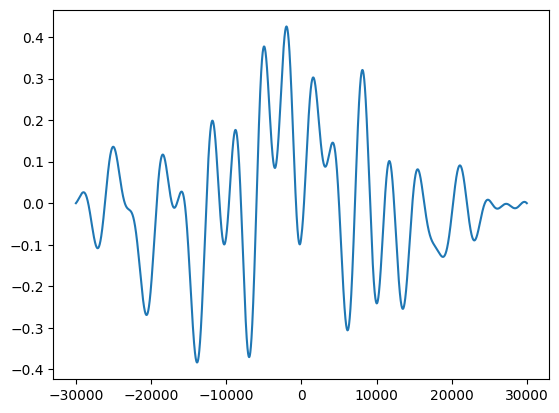

In [64]:
correlation_matrix = np.corrcoef(smoothed_signal, smoothed_signal2)
correlation_matrix
x_norm = (smoothed_signal - np.mean(smoothed_signal)) / np.std(smoothed_signal)
y_norm = (smoothed_signal2 - np.mean(smoothed_signal2)) / np.std(smoothed_signal2)
cross_corr = np.correlate(x_norm, y_norm, mode='full')
norm_factor = np.sqrt(np.sum(x_norm**2) * np.sum(y_norm**2))
cross_corr = cross_corr / norm_factor
lags = np.arange(-len(smoothed_signal2) + 1, len(smoothed_signal))
plt.plot(lags,cross_corr)

In [65]:
djm1 = dm1[dm1["product"] == "DJEMBES"]
dj1 = d1[d1["product"] == "DJEMBES"]
dj0 = d0[d0["product"] == "DJEMBES"]

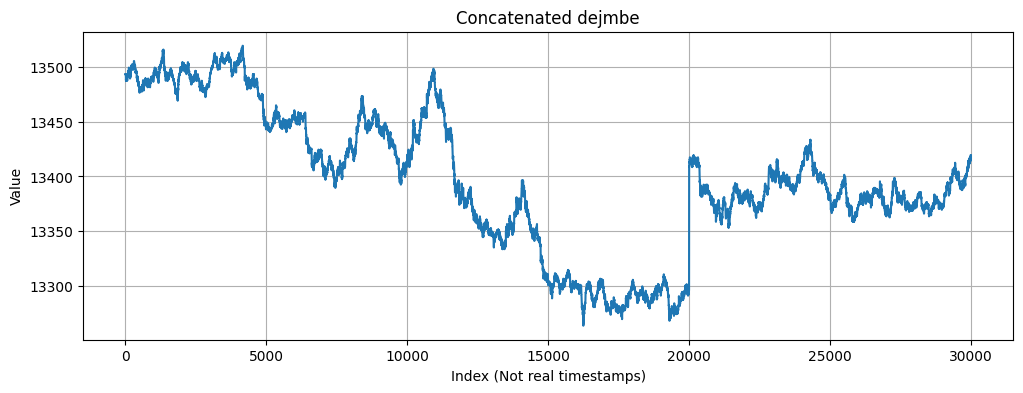

In [66]:
djm1r = djm1["mid_price"].reset_index(drop=True)
dj0r = dj0["mid_price"].reset_index(drop=True)
dj1r = dj1["mid_price"].reset_index(drop=True)


dj_concat = pd.concat([djm1r, dj0r, dj1r]).reset_index(drop=True)
plt.figure(figsize=(12, 4))
plt.plot(dj_concat)
plt.title("Concatenated dejmbe")
plt.xlabel("Index (Not real timestamps)")
plt.ylabel("Value")
plt.grid(True)
plt.show()

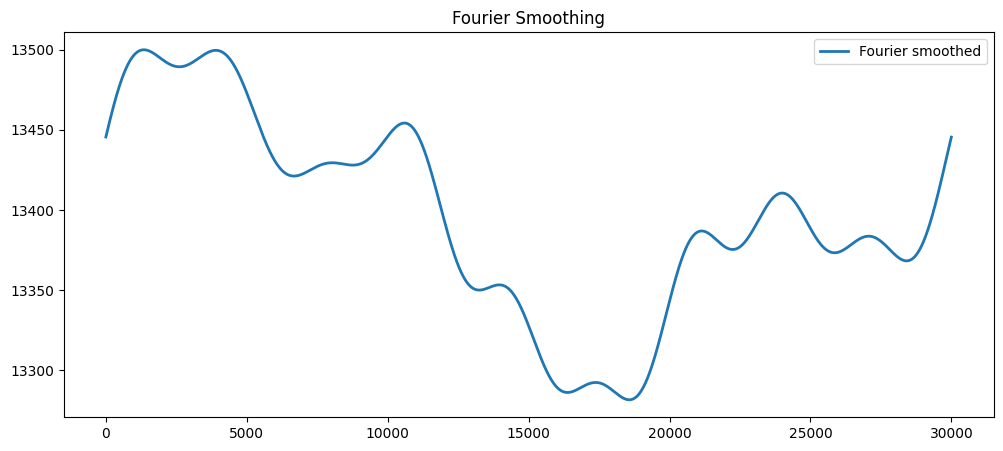

In [67]:
import numpy as np
import matplotlib.pyplot as plt
fft_vals = np.fft.fft(j_concat)
n_keep = 10  
fft_filtered = np.copy(fft_vals)
fft_filtered[n_keep:-n_keep] = 0
smoothed_signal = np.fft.ifft(fft_filtered).real

fft_vals2 = np.fft.fft(dj_concat)
n_keep = 10  
fft_filtered2 = np.copy(fft_vals2)
fft_filtered2[n_keep:-n_keep] = 0
smoothed_signal2 = np.fft.ifft(fft_filtered2).real
plt.figure(figsize=(12, 5))
plt.plot(smoothed_signal2, label='Fourier smoothed', linewidth=2)
plt.legend()
plt.title("Fourier Smoothing")
plt.show()

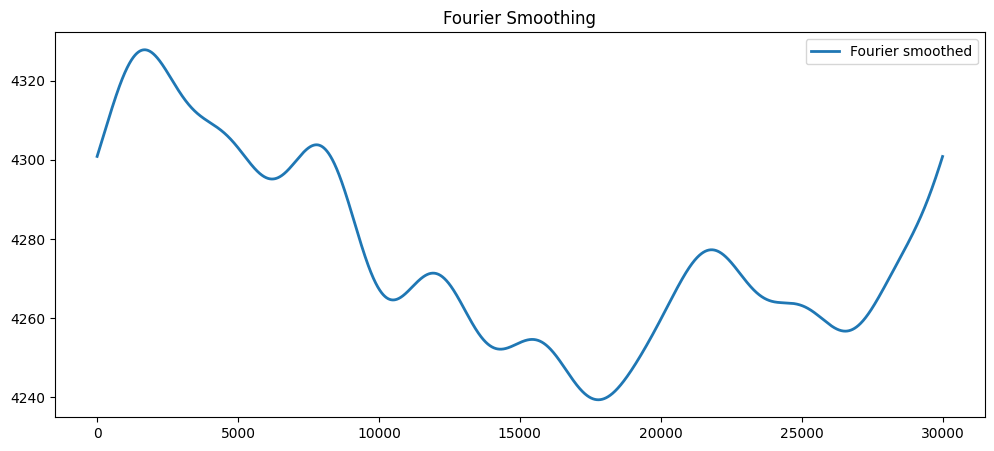

In [68]:
import numpy as np
import matplotlib.pyplot as plt
fft_vals = np.fft.fft(c_concat)
n_keep = 10  
fft_filtered = np.copy(fft_vals)
fft_filtered[n_keep:-n_keep] = 0
smoothed_signal = np.fft.ifft(fft_filtered).real

fft_vals2 = np.fft.fft(dj_concat)
n_keep = 10  
fft_filtered2 = np.copy(fft_vals2)
fft_filtered2[n_keep:-n_keep] = 0
smoothed_signal2 = np.fft.ifft(fft_filtered2).real
plt.figure(figsize=(12, 5))
plt.plot(smoothed_signal, label='Fourier smoothed', linewidth=2)
plt.legend()
plt.title("Fourier Smoothing")
plt.show()

###  Conclusion & Key Takeaways

- We **focused our analysis on the product _JAMS_**, due to time constraints preventing a proper exploration of _DJEMBES_.
- The **Augmented Dickey-Fuller (ADF) test indicates that _JAMS_ is somewhat stationary**, meaning we can confidently apply standard time series models like **EMMA** (Exponential Moving Model for Arbitrage).
- However, the **_CROISSANTS_ mid-price series is clearly non-stationary**. To address this, we need to:
  - Apply **differentiation** (e.g., first-order differencing) to make the series stationary.
  - Then apply EMMA or similar statistical models.
- That said, EMMA does **not perform as well for _CROISSANTS_** due to the higher and more variable volatility.
- A better approach for _CROISSANTS_ may involve using a **time-varying alpha (learning rate)** in EMMA — making it **adaptive to local volatility** and market regime changes.


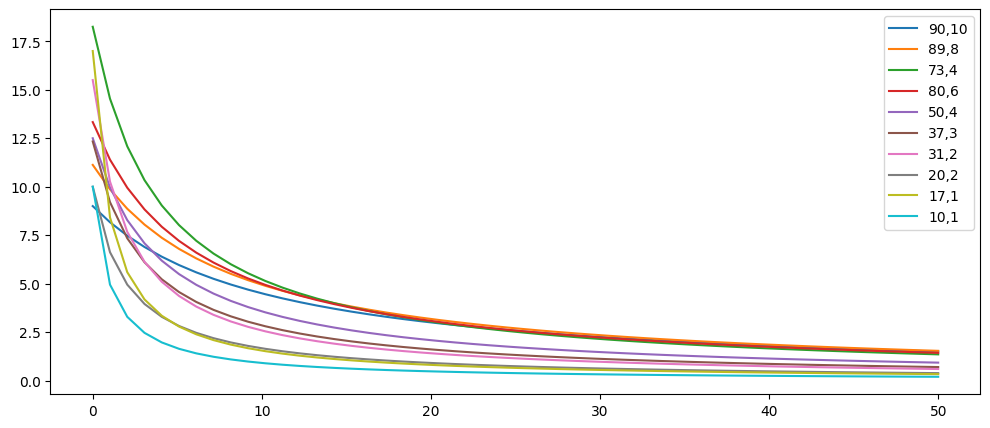

In [69]:
cont_dict={

    90 : 10,
    89: 8,
    73: 4,
    80: 6,
    50:4,
    37:3,
    31:2,
    20:2,
    17:1,
    10:1

}
plt.figure(figsize=(12, 5))
x = np.linspace(0,50)
for i in cont_dict.keys():
    plt.plot(x,i/(cont_dict[i] + x) , label = str(i)+","+str(cont_dict[i]))
plt.legend()

{90: 0.29800803907948914, 89: 0.2973465342702136, 73: 0.1567885748361404, 80: 0.23862618326084076, 50: 0.008512748874127465, 37: 0.0005797827820456323, 31: 0.00013023235306447317, 20: 5.562161840979946e-06, 17: 2.1439577131680775e-06, 10: 1.984245245114603e-07}


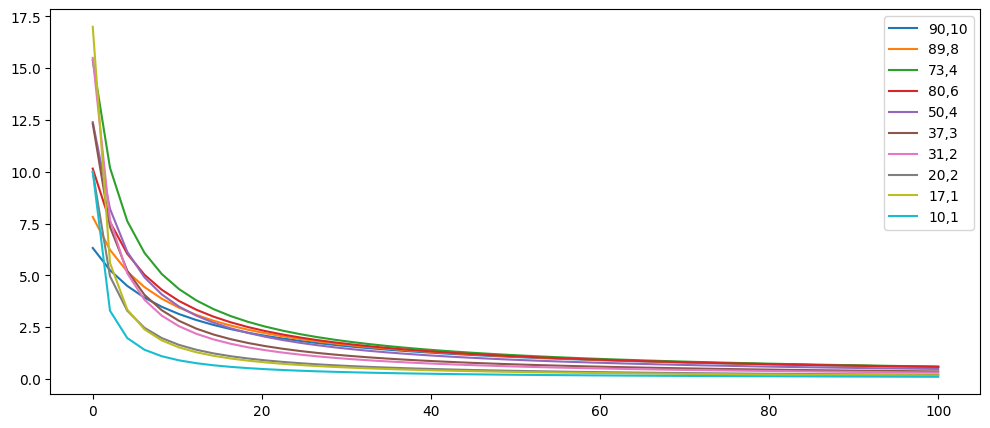

In [70]:
values = np.array(list(cont_dict.keys()))
from scipy.stats import norm

# Pick parameters for Gaussian
mu = np.max(values)  # center at highest value
sigma = 15  # controls the spread

# Gaussian-based weights
weights = norm.pdf(values, loc=mu, scale=sigma)

# Normalize to make it a probability distribution
probs = weights / weights.sum()

# Associate to each key
gaussian_probs = dict(zip(values, probs))

print(gaussian_probs)
plt.figure(figsize=(12, 5))
x = np.linspace(0,100)
for i in cont_dict.keys():
    plt.plot(x,(1-gaussian_probs[i])*i/(cont_dict[i] + x) , label = str(i)+","+str(cont_dict[i]))
plt.legend()